In [5]:
FEATURE_NAMES = [
    "pos_carro",       # posición horizontal del carro
    "vel_carro",       # velocidad horizontal del carro
    "angulo_palo",     # ángulo del palo respecto a la vertical
    "vel_ang_palo",    # velocidad angular del palo
]

ACTION_NAMES = [
    "izquierda",   # 0: empujar carro a la izquierda
    "derecha",     # 1: empujar carro a la derecha
]

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import gymnasium as gym
from typing import Optional
import shap
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
from dqn import DQNAgent, DQNNetwork

In [ ]:
agent = DQNAgent(4,2)
final_model_path = 'models/dqn_cartpole'
agent.load(final_model_path)

In [46]:
def recolectar_dataset(policy_net, n_episodes=200):
    env = gym.make("CartPole-v1")
    X, y = [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0).to(agent.device)
            with torch.no_grad():
                action = policy_net(obs_t).argmax(dim=-1).item()
            X.append(obs)
            y.append(action)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
    env.close()
    return np.array(X), np.array(y)

X, y = recolectar_dataset(agent.policy_net, n_episodes=100)

print("Dataset:", X.shape, y.shape)
print("Distribución de acciones:", np.bincount(y))

Dataset: (50000, 4) (50000,)
Distribución de acciones: [25011 24989]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
device = next(policy_net.parameters()).device

def q_values(obs_batch):
    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32).to(device)
    with torch.no_grad():
        q_values = policy_net(obs_t)
    return q_values.cpu().numpy()
explainer = shap.KernelExplainer(q_values, shap.sample(X_train, 1000))
shap_values = explainer.shap_values(X_test[:500])


Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:01<00:00, 285.92it/s]


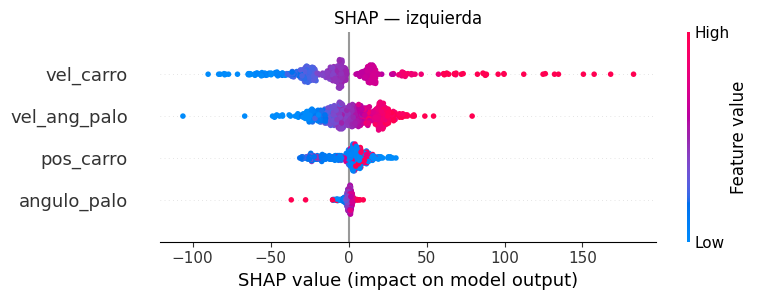

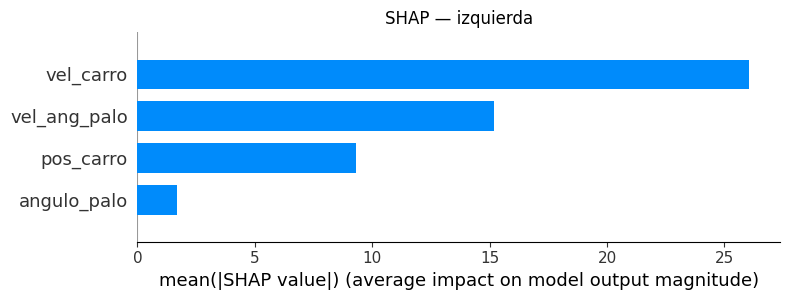

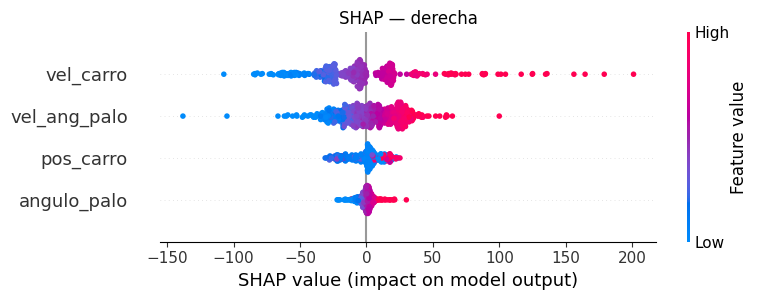

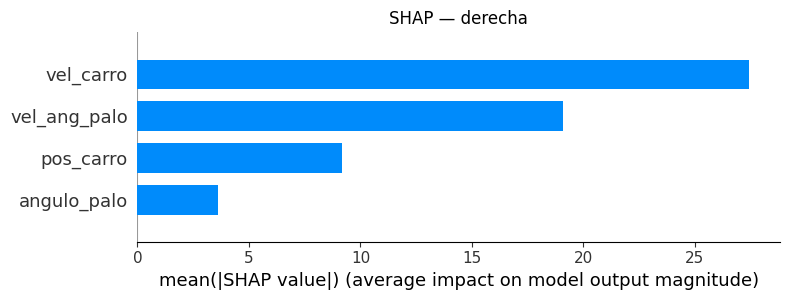

In [ ]:
shap_arr = np.array(shap_values)
import matplotlib.pyplot as plt

for i in range(len(ACTION_NAMES)):
    shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, show=False)
    plt.title(f"SHAP — {ACTION_NAMES[i]}")
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, plot_type="bar", show=False)
    plt.title(f"SHAP — {ACTION_NAMES[i]}")
    plt.tight_layout()
    plt.show()

In [40]:
device = next(policy_net.parameters()).device

def advantage_values(obs_batch):
    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32).to(device)
    with torch.no_grad():
        q = policy_net(obs_t)               # (n, n_acciones)
        v = q.mean(dim=-1, keepdim=True)    # V(s) ≈ media de Q
        advantage = q - v                   # A(s,a) = Q(s,a) - V(s)
    return advantage.cpu().numpy()

explainer = shap.KernelExplainer(advantage_values, shap.sample(X_train, 1000))
shap_values = explainer.shap_values(X_test[:500])

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:01<00:00, 273.80it/s]


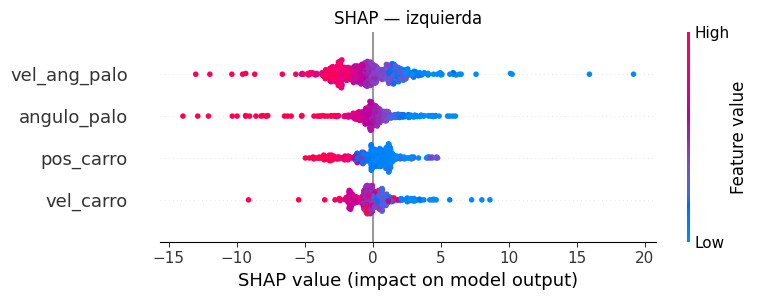

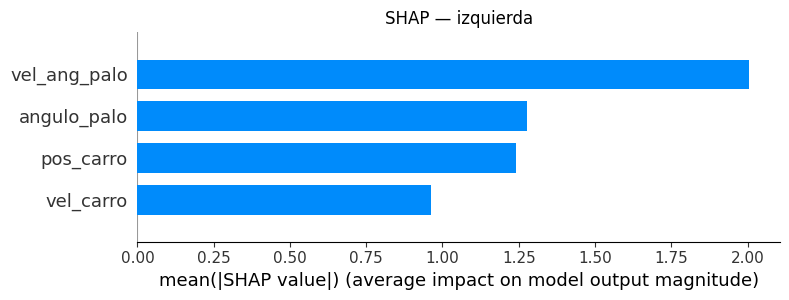

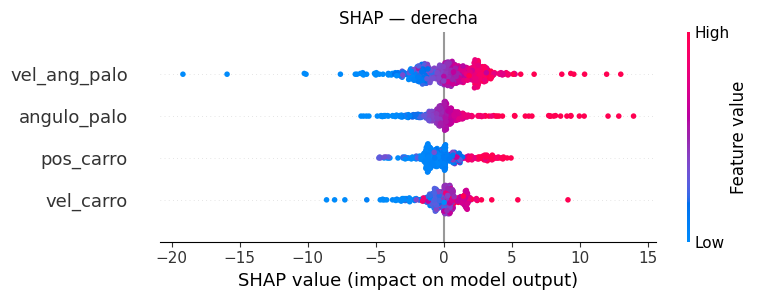

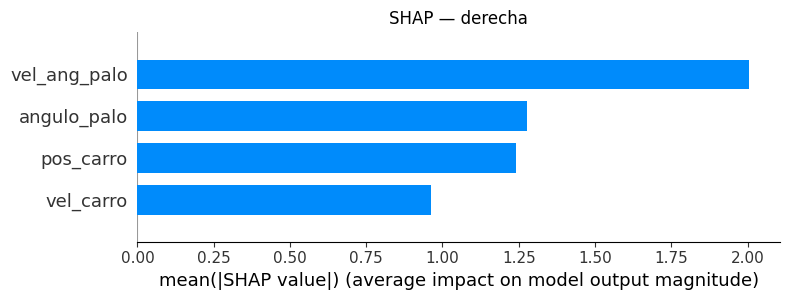

In [42]:
shap_arr = np.array(shap_values)
import matplotlib.pyplot as plt

for i in range(len(ACTION_NAMES)):
    shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, show=False)
    plt.title(f"SHAP — {ACTION_NAMES[i]}")
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, plot_type="bar", show=False)
    plt.title(f"SHAP — {ACTION_NAMES[i]}")
    plt.tight_layout()
    plt.show()

In [24]:
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs A2C): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))

Fidelidad (accuracy vs A2C): 0.853
              precision    recall  f1-score   support

   izquierda       0.83      0.89      0.86      5003
     derecha       0.88      0.82      0.85      4997

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [25]:
for d in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")

depth= 2  fidelidad=0.806
depth= 3  fidelidad=0.834
depth= 4  fidelidad=0.834
depth= 5  fidelidad=0.838
depth= 6  fidelidad=0.853
depth= 8  fidelidad=0.885
depth=10  fidelidad=0.905
depth=15  fidelidad=0.919
depth=20  fidelidad=0.919


|--- vel_ang_palo <= 0.07
|   |--- angulo_palo <= 0.01
|   |   |--- vel_ang_palo <= -0.12
|   |   |   |--- angulo_palo <= 0.01
|   |   |   |   |--- vel_ang_palo <= -0.15
|   |   |   |   |   |--- vel_carro <= 0.83
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_carro >  0.83
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_ang_palo >  -0.15
|   |   |   |   |   |--- pos_carro <= 0.16
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  0.16
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- angulo_palo >  0.01
|   |   |   |   |--- vel_ang_palo <= -0.35
|   |   |   |   |   |--- angulo_palo <= 0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- angulo_palo >  0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_ang_palo >  -0.35
|   |   |   |   |   |--- pos_carro <= 0.18
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  0.18
|   |   |   |   |   |   |--- class: 0
|   |   |---

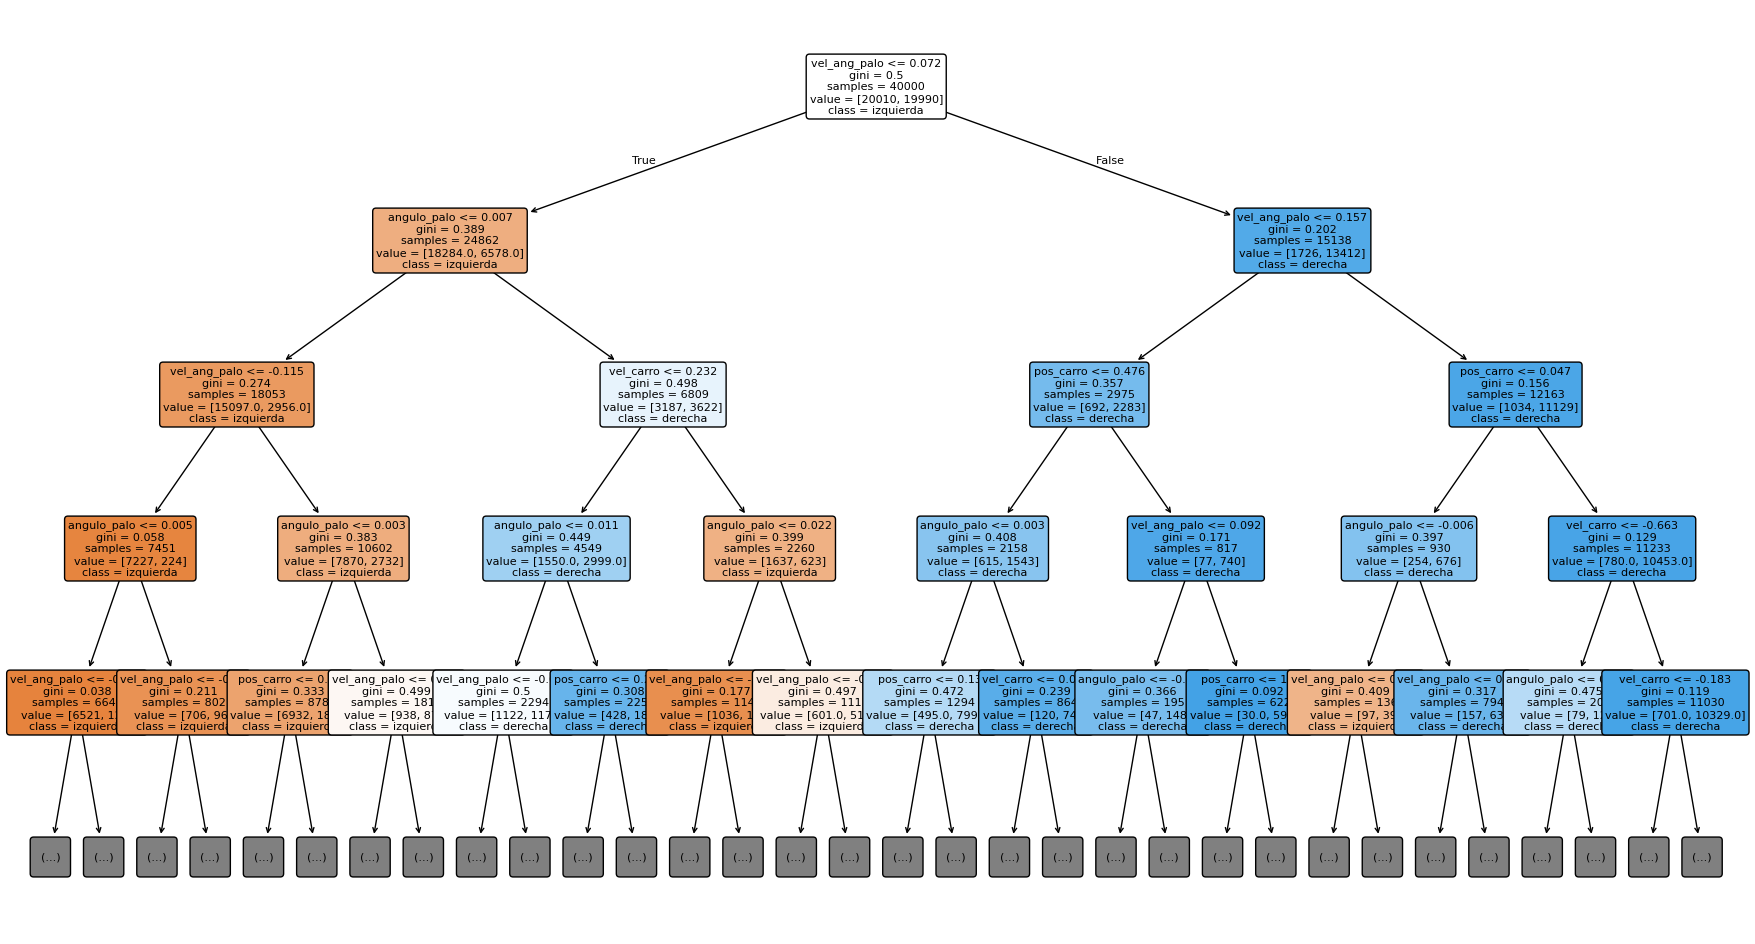

In [26]:
print(export_text(tree, feature_names=FEATURE_NAMES))

# Árbol gráfico
plt.figure(figsize=(22, 12))
plot_tree(
    tree,
    feature_names=FEATURE_NAMES,
    class_names=ACTION_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,  # recorta el dibujo para que sea legible
)
# plt.savefig("arbol_cartpole.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
def evaluar_politica_arbol(tree, n_episodes=20):
    env = gym.make("CartPole-v1")
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = int(tree.predict(obs.reshape(1, -1))[0])
            obs, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)

m, s = evaluar_politica_arbol(tree)
print(f"Recompensa del árbol sustituto: {m:.1f} ± {s:.1f}")

Recompensa del árbol sustituto: 422.9 ± 108.9


vel_ang_palo    0.686146
angulo_palo     0.175582
pos_carro       0.081726
vel_carro       0.056546
dtype: float64


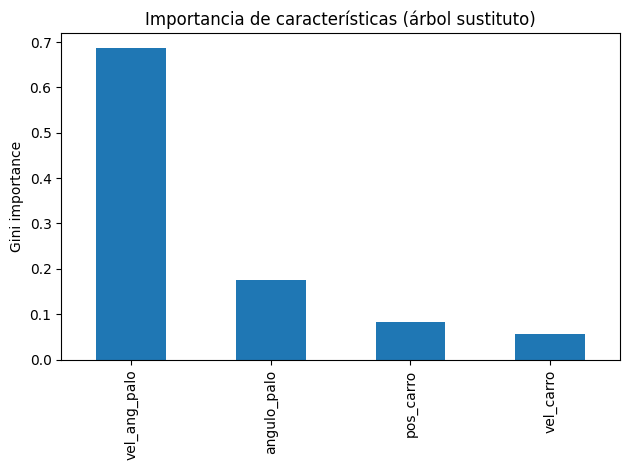

In [28]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características (árbol sustituto)", ylabel="Gini importance")
plt.tight_layout()
plt.savefig("importancia_cartpole.png", dpi=150)
plt.show()